In [797]:
import pandas as pd
import numpy as np
from pathlib import Path

imu_data_file_path = "ins_28_04_26\SensorConnectData__1.csv"
cuaternion_file_path = "ins_28_04_26\QuaternionEst__1.csv"

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\Q'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\Q'
C:\Users\JUANALVA\AppData\Local\Temp\ipykernel_12048\2847478223.py:5: SyntaxWarning: invalid escape sequence '\S'
  imu_data_file_path = "ins_28_04_26\SensorConnectData__1.csv"
C:\Users\JUANALVA\AppData\Local\Temp\ipykernel_12048\2847478223.py:6: SyntaxWarning: invalid escape sequence '\Q'
  cuaternion_file_path = "ins_28_04_26\QuaternionEst__1.csv"


In [798]:
def find_csv_header_line(filepath, required_first_col="Time"):
    filepath = Path(filepath)

    with filepath.open("r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        clean = line.strip()

        if clean.startswith(required_first_col + ","):
            return i

    raise ValueError(
        f"No se encontró una línea de encabezado que empiece con '{required_first_col},'"
    )

In [799]:
def read_generic_sensor_csv(filepath):
    header_line = find_csv_header_line(filepath, required_first_col="Time")

    df = pd.read_csv(
        filepath,
        skiprows=header_line,
        sep=",",
        skipinitialspace=True
    )

    df.columns = [c.strip() for c in df.columns]

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Time"]).copy()
    df = df.sort_values("Time").reset_index(drop=True)

    return df

In [800]:
df_imu_all = read_generic_sensor_csv(imu_data_file_path)
# print(df.columns[:])
# df
cols = ['Time', 'estLinearAccelX', 'estLinearAccelY', 'estLinearAccelZ', 'estAngularRateX', 'estAngularRateY','estAngularRateZ']
df_imu = df_imu_all[cols].copy()
# df_accel.head()
df_imu = df_imu.rename(columns={
    "estLinearAccelX": "alx",
    "estLinearAccelY": "aly",
    "estLinearAccelZ": "alz",
    "estAngularRateX": "agx",
    "estAngularRateY": "agy",
    "estAngularRateZ": "agz"
})
df_imu

,Time,alx,aly,alz,agx,agy,agz
0,1777415753006350596,-0.005004,0.029466,0.055045,-0.001042,0.003331,0.016892
1,1777415753016559684,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396
2,1777415753026651662,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396
3,1777415753036301759,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263
4,1777415753046387868,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263
...,...,...,...,...,...,...,...
4697,1777415809836295834,-0.334132,-0.039574,0.040694,-0.001293,0.002965,0.017143
4698,1777415809846528987,-0.334132,-0.039574,0.040694,-0.001293,0.002965,0.017143
4699,1777415809856109952,-0.350269,-0.038060,0.028760,-0.001754,0.002797,0.017989
4700,1777415809866383216,-0.350269,-0.038060,0.028760,-0.001754,0.002797,0.017989


In [801]:
df_quat = read_generic_sensor_csv(cuaternion_file_path)
# print(df_quat)
df_quat = df_quat.rename(columns={
    "estOrientQuaternion[0-0]": "q0",
    "estOrientQuaternion[0-1]": "q1",
    "estOrientQuaternion[0-2]": "q2",
    "estOrientQuaternion[0-3]": "q3"
})
# df_q
df_quat = df_quat[['Time','q0', 'q1', 'q2', 'q3', 'flagStop']].copy()
df_quat

,Time,q0,q1,q2,q3,flagStop
0,1777415753006350596,0.999987,0.005049,0.000979,0.000191,0
1,1777415753016559684,0.977315,-0.005265,0.028184,0.209840,0
2,1777415753026651662,0.977315,-0.005265,0.028184,0.209840,0
3,1777415753036301759,0.977277,-0.005277,0.028206,0.210016,0
4,1777415753046387868,0.977277,-0.005277,0.028206,0.210016,0
...,...,...,...,...,...,...
4697,1777415809836295834,0.736187,-0.011030,0.013631,0.676551,1
4698,1777415809846528987,0.736187,-0.011030,0.013631,0.676551,1
4699,1777415809856109952,0.736063,-0.011060,0.013641,0.676685,1
4700,1777415809866383216,0.736063,-0.011060,0.013641,0.676685,1


In [802]:
import pandas as pd

# Asegurar que Time sea numérico
df_imu["Time"] = pd.to_numeric(df_imu["Time"], errors="coerce")
df_quat["Time"] = pd.to_numeric(df_quat["Time"], errors="coerce")

# Eliminar filas inválidas
df_imu = df_imu.dropna(subset=["Time"]).copy()
df_quat = df_quat.dropna(subset=["Time"]).copy()

# Ordenar obligatoriamente para merge_asof
df_imu = df_imu.sort_values("Time").reset_index(drop=True)
df_quat = df_quat.sort_values("Time").reset_index(drop=True)

# Tolerancia en nanosegundos
# Ejemplo: 5 ms = 5_000_000 ns
tol_ns = 5_000_000

df_merge = pd.merge_asof(
    df_imu,
    df_quat,
    on="Time",
    direction="nearest",
    tolerance=tol_ns
)

print(df_merge)

                     Time       alx       aly       alz       agx       agy  \
0     1777415753006350596 -0.005004  0.029466  0.055045 -0.001042  0.003331   
1     1777415753016559684 -0.545940 -0.106244  0.026371 -0.001580  0.001981   
2     1777415753026651662 -0.545940 -0.106244  0.026371 -0.001580  0.001981   
3     1777415753036301759 -0.555377 -0.059631  0.015700 -0.001255  0.002622   
4     1777415753046387868 -0.555377 -0.059631  0.015700 -0.001255  0.002622   
...                   ...       ...       ...       ...       ...       ...   
4697  1777415809836295834 -0.334132 -0.039574  0.040694 -0.001293  0.002965   
4698  1777415809846528987 -0.334132 -0.039574  0.040694 -0.001293  0.002965   
4699  1777415809856109952 -0.350269 -0.038060  0.028760 -0.001754  0.002797   
4700  1777415809866383216 -0.350269 -0.038060  0.028760 -0.001754  0.002797   
4701  1777415809885887619 -0.349645 -0.059650  0.022682 -0.001382  0.002958   

           agz        q0        q1        q2       

In [803]:
df_merge["timestamp"] = (df_merge["Time"] - df_merge["Time"].iloc[0]) / 1e9
df_merge["timestamp"]

0        0.000000
1        0.010209
2        0.020301
3        0.029951
4        0.040037
          ...    
4697    56.829945
4698    56.840178
4699    56.849759
4700    56.860033
4701    56.879537
Name: timestamp, Length: 4702, dtype: float64

In [804]:
df_merge["dt"] = df_merge["timestamp"].diff() / 1e9

In [805]:
df_merge[["Time", "timestamp", "dt"]].head()

,Time,timestamp,dt
0,1777415753006350596,0.000000,NaN
1,1777415753016559684,0.010209,1.020909e-11
2,1777415753026651662,0.020301,1.009198e-11
3,1777415753036301759,0.029951,9.650097e-12
4,1777415753046387868,0.040037,1.008611e-11


In [806]:
print(df_merge["dt"].describe())

fs_mean = 1 / df_merge["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    4.701000e+03
mean     1.209945e-11
std      4.003881e-12
min      9.203921e-12
25%      9.646041e-12
50%      1.015499e-11
75%      1.023036e-11
max      1.987192e-11
Name: dt, dtype: float64
Frecuencia promedio: 82648352044.41 Hz


In [807]:
df_merge.head()

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,q3,flagStop,timestamp,dt
0,1777415753006350596,-0.005004,0.029466,0.055045,-0.001042,0.003331,0.016892,0.999987,0.005049,0.000979,0.000191,0,0.000000,NaN
1,1777415753016559684,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,0.209840,0,0.010209,1.020909e-11
2,1777415753026651662,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,0.209840,0,0.020301,1.009198e-11
3,1777415753036301759,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,0.210016,0,0.029951,9.650097e-12
4,1777415753046387868,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,0.210016,0,0.040037,1.008611e-11


In [808]:
al_values = df_merge[["alx", "aly", "alz"]].values
df_merge["al_norm"] = np.linalg.norm(al_values, axis=1)

ag_values = df_merge[["agx", "agy", "agz"]].values
df_merge["ag_norm"] = np.linalg.norm(ag_values, axis=1)

In [809]:
df_init = df_merge[df_merge["timestamp"] <= 20.0].copy()
df_init

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,q3,flagStop,timestamp,dt,al_norm,ag_norm
0,1777415753006350596,-0.005004,0.029466,0.055045,-0.001042,0.003331,0.016892,0.999987,0.005049,0.000979,0.000191,0,0.000000,NaN,0.062636,0.017249
1,1777415753016559684,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,0.209840,0,0.010209,1.020909e-11,0.556807,0.018570
2,1777415753026651662,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,0.209840,0,0.020301,1.009198e-11,0.556807,0.018570
3,1777415753036301759,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,0.210016,0,0.029951,9.650097e-12,0.558790,0.018493
4,1777415753046387868,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,0.210016,0,0.040037,1.008611e-11,0.558790,0.018493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1679,1777415772947754127,-0.154721,0.025911,0.038131,-0.001530,0.002885,0.017180,0.910694,-0.001397,0.009149,0.412978,1,19.941404,1.015380e-11,0.161443,0.017488
1680,1777415772957290144,-0.150282,0.013685,0.040256,-0.002190,0.002968,0.017219,0.910622,-0.001429,0.009167,0.413136,1,19.950940,9.536017e-12,0.156181,0.017610
1681,1777415772967444335,-0.150282,0.013685,0.040256,-0.002190,0.002968,0.017219,0.910622,-0.001429,0.009167,0.413136,1,19.961094,1.015419e-11,0.156181,0.017610
1682,1777415772977022814,-0.147289,0.014222,0.037907,-0.001944,0.003600,0.017124,0.910551,-0.001460,0.009193,0.413291,1,19.970672,9.578479e-12,0.152752,0.017606


In [810]:
def normalized(v, eps=1e-12):
    norm = np.linalg.norm(v)
    if norm < eps:
        return v
    return v / norm


def initialize_ins_from_dataframe(
    df,
    init_time=5.0,
    time_col="timestamp",
    gyro_cols=("agx", "agy", "agz"),
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    noise_coefficient={"w": 100, "a": 100},
    discard_edges=10
):
    """
    Inicializa parámetros básicos para un INS/EKF usando una ventana inicial
    donde el vehículo/IMU debe estar quieto.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con columnas de tiempo, aceleración, giro y cuaternión.

    init_time : float
        Tiempo inicial en segundos usado para inicialización.

    time_col : str
        Columna de tiempo relativo en segundos.

    gyro_cols : tuple
        Columnas de velocidad angular.

    acc_cols : tuple
        Columnas de aceleración.

    quat_cols : tuple
        Columnas de cuaternión.

    noise_coefficient : dict
        Factor multiplicador para estimar ruido a partir de varianza.

    discard_edges : int
        Número de muestras iniciales y finales a descartar dentro de la ventana.

    Retorna:
    --------
    dict con:
        gn
        g0
        gyro_bias
        gyro_noise
        acc_noise
        acc_var
        gyro_var
        q0_mean
        df_init
    """

    required_cols = [time_col, *gyro_cols, *acc_cols, *quat_cols]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    # Copia segura
    df_work = df.copy()

    # Convertir columnas a numérico
    for c in required_cols:
        df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

    # Eliminar NaN en columnas importantes
    df_work = df_work.dropna(subset=required_cols).reset_index(drop=True)

    # Tomar primeros init_time segundos
    df_init = df_work[df_work[time_col] <= init_time].copy()

    if len(df_init) == 0:
        raise ValueError("No hay datos dentro de la ventana de inicialización.")

    if len(df_init) <= 2 * discard_edges:
        raise ValueError("No hay suficientes muestras para descartar bordes.")

    # Descartar bordes para evitar muestras corruptas o transitorios
    df_init_cut = df_init.iloc[discard_edges:-discard_edges].reset_index(drop=True)

    # Extraer arrays
    w = df_init_cut[list(gyro_cols)].to_numpy()
    a = df_init_cut[list(acc_cols)].to_numpy()
    q = df_init_cut[list(quat_cols)].to_numpy()

    # -----------------------------
    # Gravedad inicial
    # -----------------------------
    # Si 'alx, aly, alz' son aceleración lineal SIN gravedad,
    # entonces esto NO representa gravedad.
    #
    # Si fueran aceleraciones crudas scaledAccel, sí podrías estimar gravedad.
    gn = -a.mean(axis=0)
    gn = gn[:, np.newaxis]

    g0 = np.linalg.norm(gn)

    # -----------------------------
    # Bias inicial del giroscopio
    # -----------------------------
    acc_bias = a.mean(axis=0)
    gyro_bias = w.mean(axis=0)

    # -----------------------------
    # Varianzas
    # -----------------------------
    acc_var = a.var(axis=0)
    gyro_var = w.var(axis=0)

    gyro_noise = noise_coefficient["w"] * np.linalg.norm(gyro_var)
    acc_noise = noise_coefficient["a"] * np.linalg.norm(acc_var)

    # Vectores
    ## Acel
    al_norm_mean  = np.mean(df_merge["al_norm"])
    al_norm_var   = np.var(df_merge["al_norm"])
    al_norm_std   = np.std(df_merge["al_norm"])
    
    al_norm_th_value = al_norm_mean + 3*al_norm_std

    ## Giros
    ag_norm_mean  = np.mean(df_merge["al_norm"])
    ag_norm_var   = np.var(df_merge["al_norm"])
    ag_norm_std   = np.std(df_merge["al_norm"])
    
    ag_norm_th_value = ag_norm_mean + 3*ag_norm_std

    # -----------------------------
    # Cuaternión inicial promedio simple
    # -----------------------------
    q_mean = q.mean(axis=0)
    q_mean = normalized(q_mean)

    df_init["acc_norm"] = np.sqrt(df_init["alx"]**2 + df_init["aly"]**2 + df_init["alz"]**2)

    print(df_init["acc_norm"].describe())

    print("Muestras usadas:", len(df_init_cut))
    print("Tiempo inicial usado:", df_init_cut[time_col].iloc[0], "a", df_init_cut[time_col].iloc[-1], "s")
    print("acc mean:", a.mean(axis=0))
    print("gyro mean / gyro bias:", gyro_bias)
    print("acc var:", acc_var, "norm:", np.linalg.norm(acc_var))
    print("gyro var:", gyro_var, "norm:", np.linalg.norm(gyro_var))
    print("g0 estimado:", g0)
    print("q inicial promedio:", q_mean)

    return {
        "gn": gn,
        "g0": g0,
        "acc_bias":acc_bias,
        "gyro_bias": gyro_bias,
        "gyro_noise": gyro_noise,
        "acc_noise": acc_noise,
        "acc_var": acc_var,
        "gyro_var": gyro_var,
        "al_norm_mean": al_norm_mean,
        "al_norm_std": al_norm_std,
        "al_norm_th_value": al_norm_th_value,
        "ag_norm_mean": ag_norm_mean,
        "ag_norm_std": ag_norm_std,
        "ag_norm_th_value": ag_norm_std, 
        "q0_mean": q_mean,
        "df_init": df_init_cut
    }

In [811]:
init_values = initialize_ins_from_dataframe(
    df_merge,
    init_time=1.0,
    time_col="timestamp",
    gyro_cols=("agx", "agy", "agz"),
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    noise_coefficient={"w": 100, "a": 100},
    discard_edges=10
)

count    84.000000
mean      0.560107
std       0.060550
min       0.062636
25%       0.556991
50%       0.565811
75%       0.575355
max       0.617162
Name: acc_norm, dtype: float64
Muestras usadas: 64
Tiempo inicial usado: 0.10470537 a 0.869758609 s
acc mean: [-0.5574997  -0.06965639  0.02431441]
gyro mean / gyro bias: [-0.00069484  0.00379581  0.01863127]
acc var: [0.00053689 0.00668144 0.00014392] norm: 0.0067045246071663145
gyro var: [4.96084844e-06 2.67113656e-06 1.02965813e-05] norm: 1.1737315425429887e-05
g0 estimado: 0.5623603134029425
q inicial promedio: [ 0.97635661 -0.00544411  0.02864812  0.21419014]


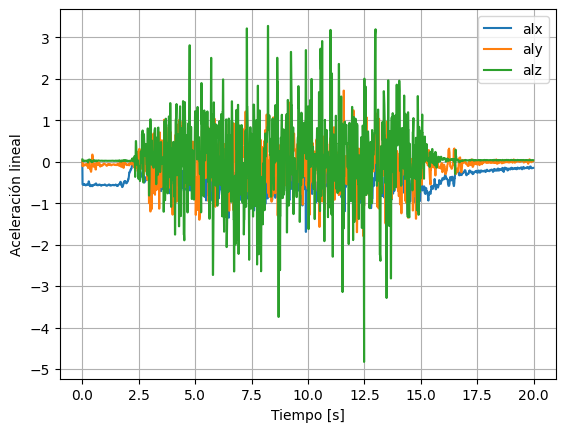

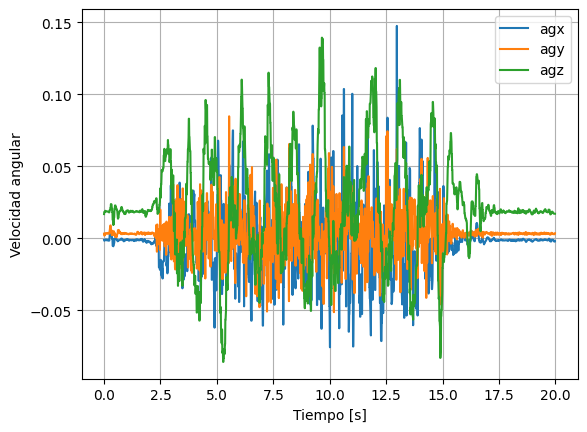

In [812]:
import matplotlib.pyplot as plt

df_init = df_merge[df_merge["timestamp"] <= 20.0]

plt.figure()
plt.plot(df_init["timestamp"], df_init["alx"], label="alx")
plt.plot(df_init["timestamp"], df_init["aly"], label="aly")
plt.plot(df_init["timestamp"], df_init["alz"], label="alz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración lineal")
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(df_init["timestamp"], df_init["agx"], label="agx")
plt.plot(df_init["timestamp"], df_init["agy"], label="agy")
plt.plot(df_init["timestamp"], df_init["agz"], label="agz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad angular")
plt.grid()
plt.legend()
plt.show()

In [813]:
gn = init_values["gn"]
g0 = init_values["g0"]
acc_bias = init_values["acc_bias"]
gyro_bias = init_values["gyro_bias"]
gyro_noise = init_values["gyro_noise"]
acc_noise = init_values["acc_noise"]
q0_mean = init_values["q0_mean"]
biases = {
    "alx": acc_bias[0],
    "aly": acc_bias[1],
    "alz": acc_bias[2],
    "agx": gyro_bias[0],
    "agy": gyro_bias[1],
    "agz": gyro_bias[2],
}

biases

{'alx': np.float64(-0.557499703125),
 'aly': np.float64(-0.069656390625),
 'alz': np.float64(0.02431440625),
 'agx': np.float64(-0.00069484375),
 'agy': np.float64(0.0037958124999999997),
 'agz': np.float64(0.018631265624999997)}

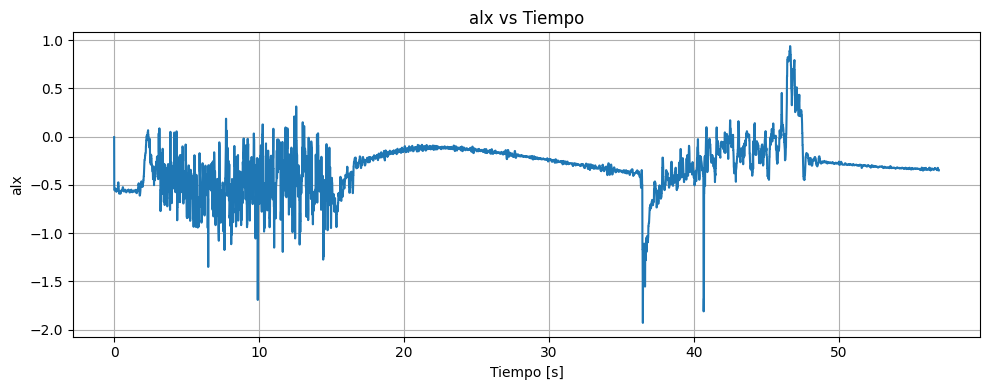

alx


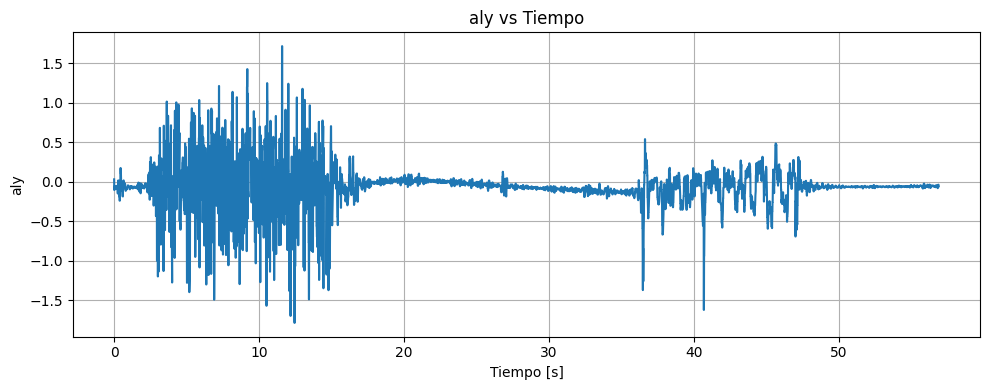

aly


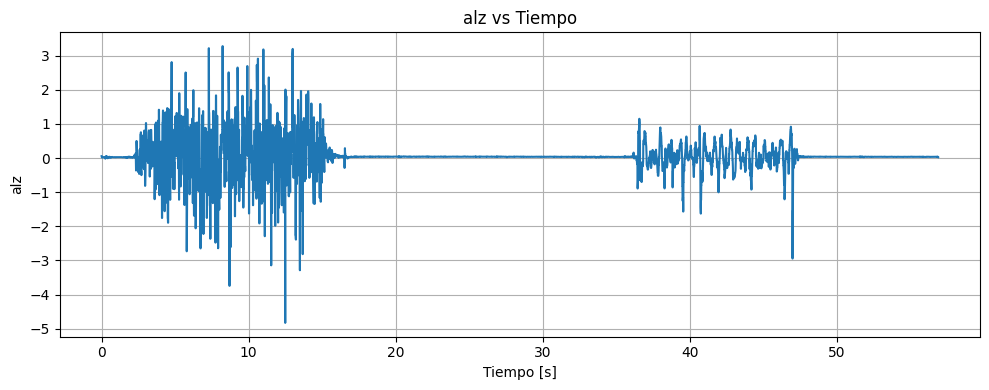

alz


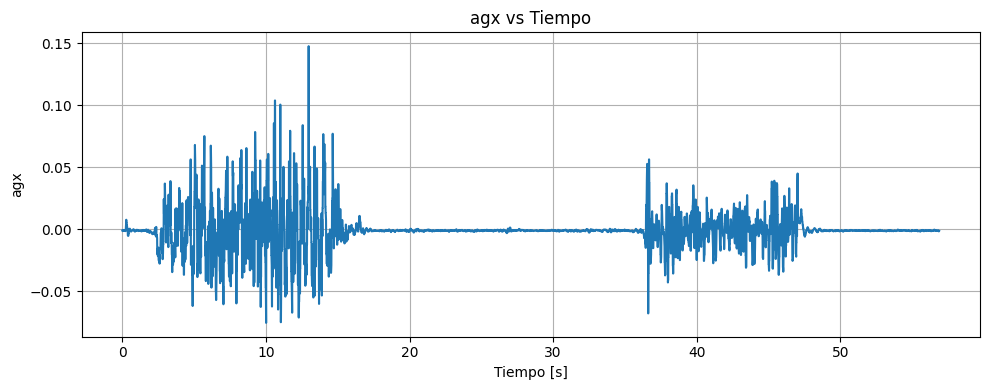

agx


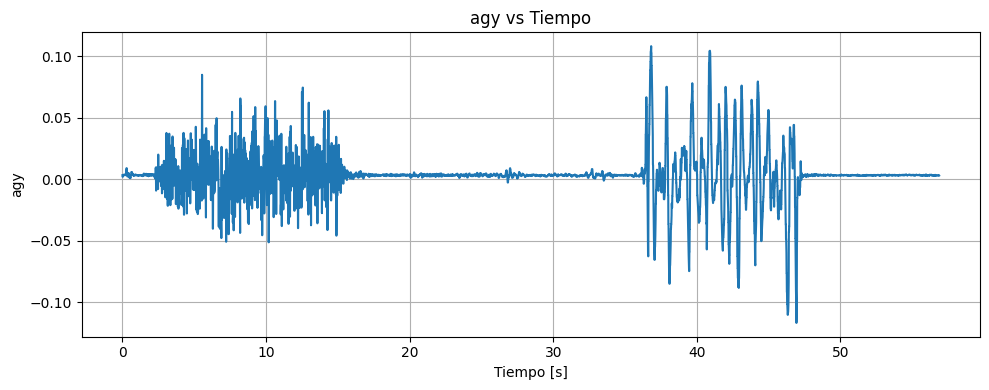

agy


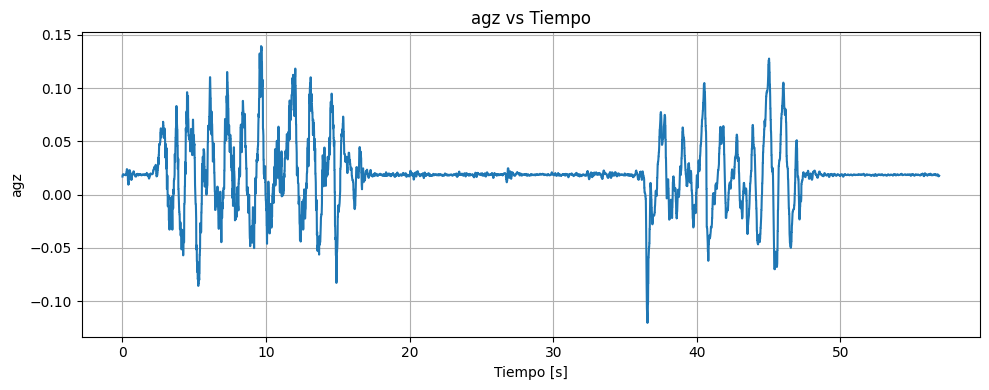

agz


In [814]:
# sigma = 0.01 # desviación estandar

# rudio_gyro = np.random.normal(loc=0, scale=sigma, size=n)

# # plt.plot(np.arange(n) * dt, rudio_gyro)
# plt.xlabel("Tiempo [s]")
# # plt.ylabel("Ruido del giroscopio [deg/s]")
# # plt.title("Ruido blanco en velocidad angular")
# # plt.grid()
# # plt.show()

# print(df.columns[3])
def plot_data_vs_time(df, col):
    df = df.copy()

    # Convertir Time a numérico
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

    # Eliminar filas donde Time no pudo convertirse
    # df = df.dropna(subset=["Time"])

    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # print(t)

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # print(df[col])

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col)
    plt.title(f"{col} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
        
# plot_data_vs_time(df=df, col="scaledAccelY")

for column in df_merge.columns[1:7]:
    plot_data_vs_time(df=df_merge, col=column)
    print(column)


In [815]:
df_merge.columns[:]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'flagStop', 'timestamp', 'dt', 'al_norm', 'ag_norm'],
      dtype='str')

In [816]:
# Etapa de filtrado

alx = df_merge['alx'].values
aly = df_merge['aly'].values
alz = df_merge['alz'].values
agx = df_merge['agx'].values
agy = df_merge['agy'].values
agz = df_merge['agz'].values

ang_acc = np.vstack((alx, aly, alz, agx, agy, agz)).T

ang_acc

array([[-0.005004,  0.029466,  0.055045, -0.001042,  0.003331,  0.016892],
       [-0.54594 , -0.106244,  0.026371, -0.00158 ,  0.001981,  0.018396],
       [-0.54594 , -0.106244,  0.026371, -0.00158 ,  0.001981,  0.018396],
       ...,
       [-0.350269, -0.03806 ,  0.02876 , -0.001754,  0.002797,  0.017989],
       [-0.350269, -0.03806 ,  0.02876 , -0.001754,  0.002797,  0.017989],
       [-0.349645, -0.05965 ,  0.022682, -0.001382,  0.002958,  0.017742]],
      shape=(4702, 6))

In [817]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fs = 100.0      # Hz
fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
agx_f = filtfilt(b, a, agx)
agy_f = filtfilt(b, a, agy)
agz_f = filtfilt(b, a, agz)
alx_f

array([-0.00495807, -0.22045983, -0.40451533, ..., -0.33968428,
       -0.34463409, -0.34969273], shape=(4702,))

In [818]:
df_merge['alx_f'] = alx_f
df_merge['aly_f'] = aly_f
df_merge['alz_f'] = alz_f
df_merge['agx_f'] = agx_f
df_merge['agy_f'] = agy_f
df_merge['agz_f'] = agz_f
df_merge.columns[:]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'flagStop', 'timestamp', 'dt', 'al_norm', 'ag_norm', 'alx_f',
       'aly_f', 'alz_f', 'agx_f', 'agy_f', 'agz_f'],
      dtype='str')

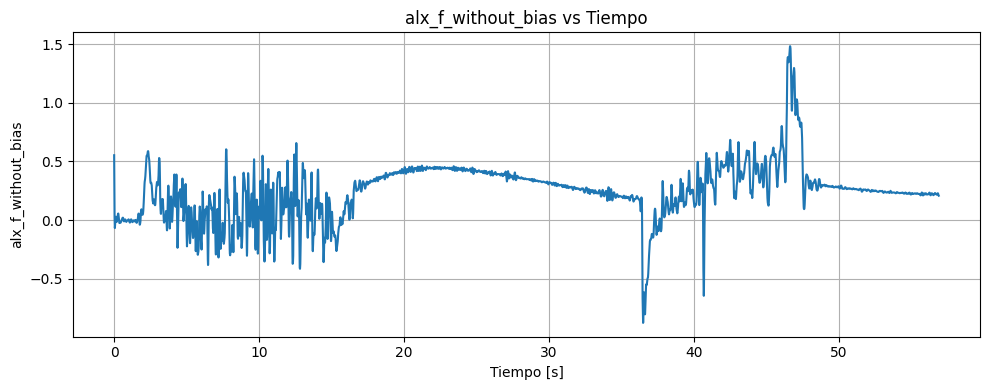

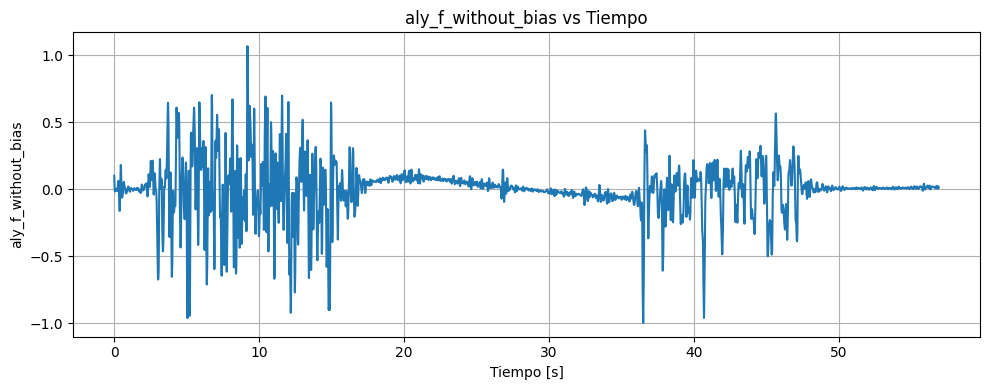

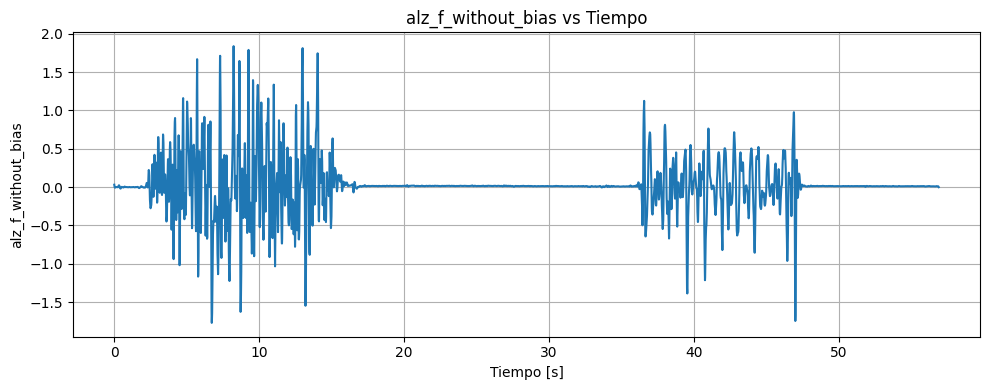

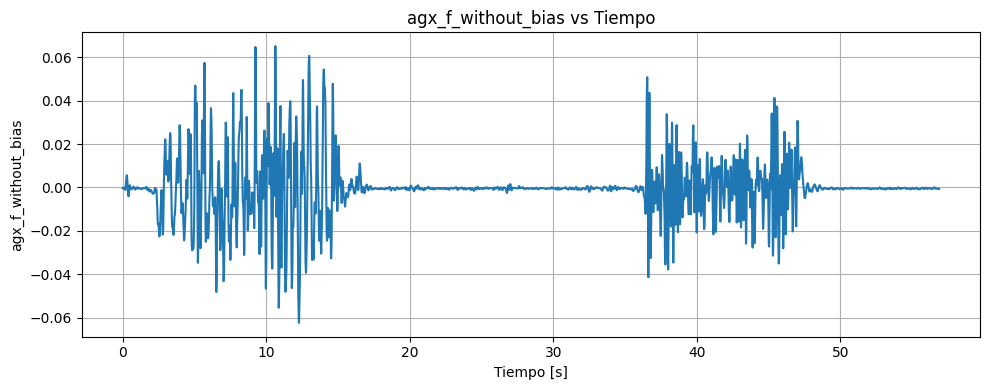

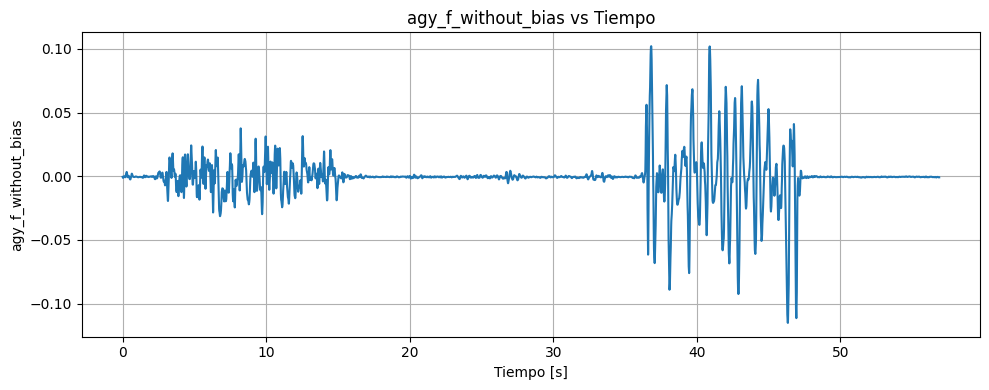

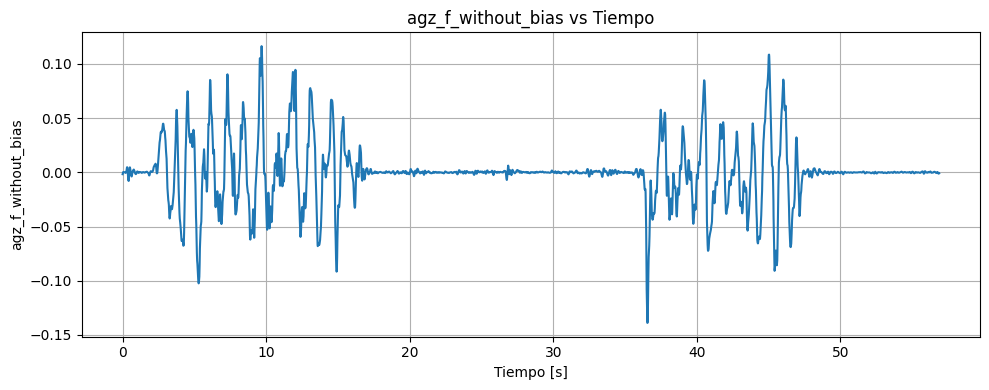

In [819]:
def data_without_bias(df, col_input, col_output):
    # print(df)
    # df[col_output] = df[col_input] - mean(df, col_input)
    # print(df[col_input])
    # print(biases[col_input])
    df[col_output] = df[col_input+"_f"] - biases[col_input]
    # print(biases)
    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col_output], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_output)
    plt.title(f"{col_output} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df_merge.columns[1:7]:
    data_without_bias(df=df_merge, col_input=column, col_output=column+"_f"+"_without_bias")
    # print(column+"_without_bias", " u:", biases[column], " o2:", var[column]," o:", std[column])

# print(df_merge.columns[13:19])

In [820]:
print(df_merge.columns[:])
df_merge["dt"]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'flagStop', 'timestamp', 'dt', 'al_norm', 'ag_norm', 'alx_f',
       'aly_f', 'alz_f', 'agx_f', 'agy_f', 'agz_f', 'alx_f_without_bias',
       'aly_f_without_bias', 'alz_f_without_bias', 'agx_f_without_bias',
       'agy_f_without_bias', 'agz_f_without_bias'],
      dtype='str')


0                NaN
1       1.020909e-11
2       1.009198e-11
3       9.650097e-12
4       1.008611e-11
            ...     
4697    9.583983e-12
4698    1.023315e-11
4699    9.580965e-12
4700    1.027326e-11
4701    1.950440e-11
Name: dt, Length: 4702, dtype: float64

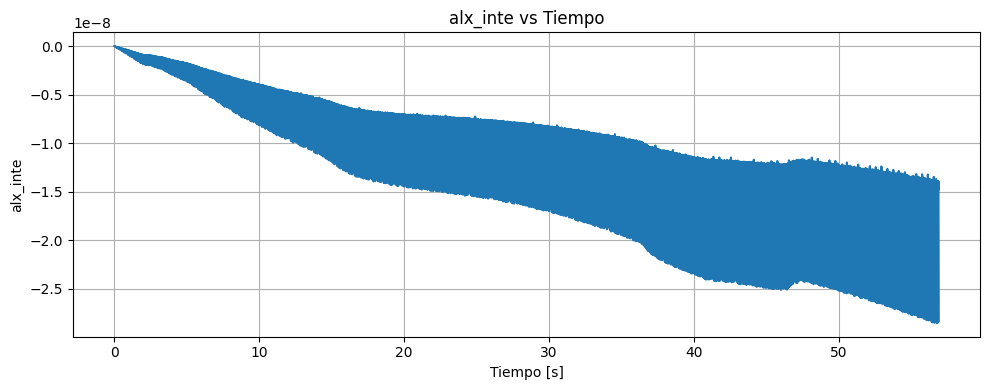

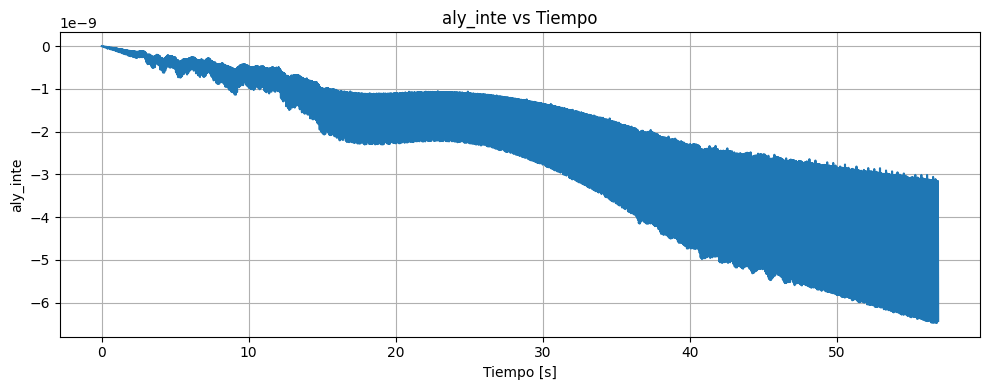

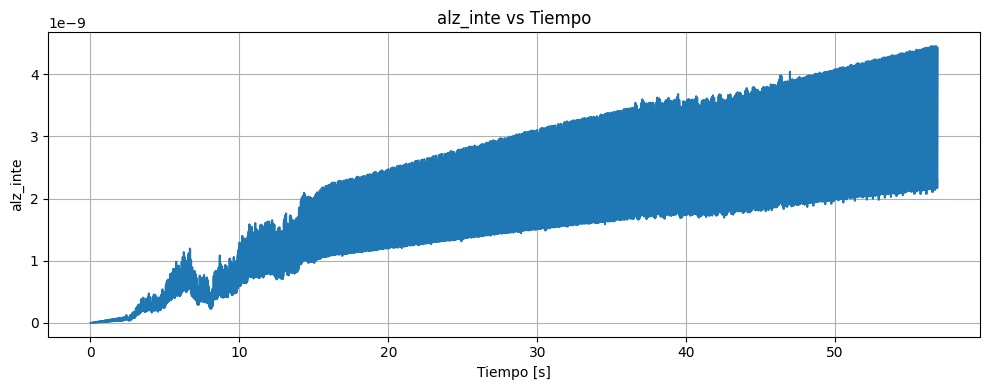

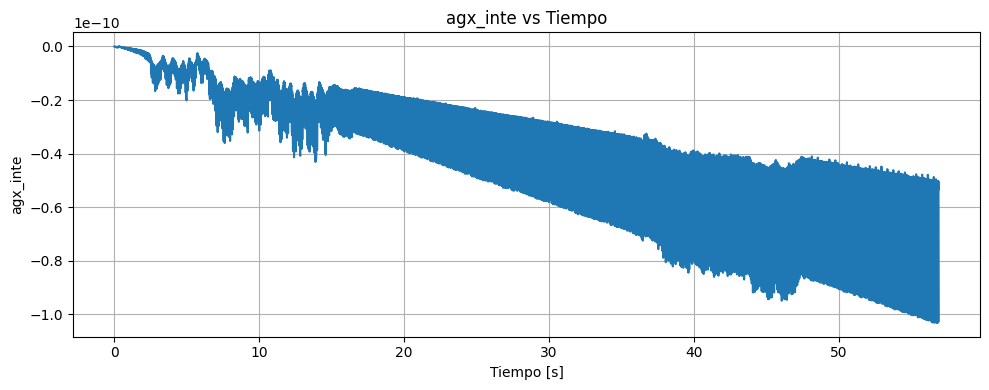

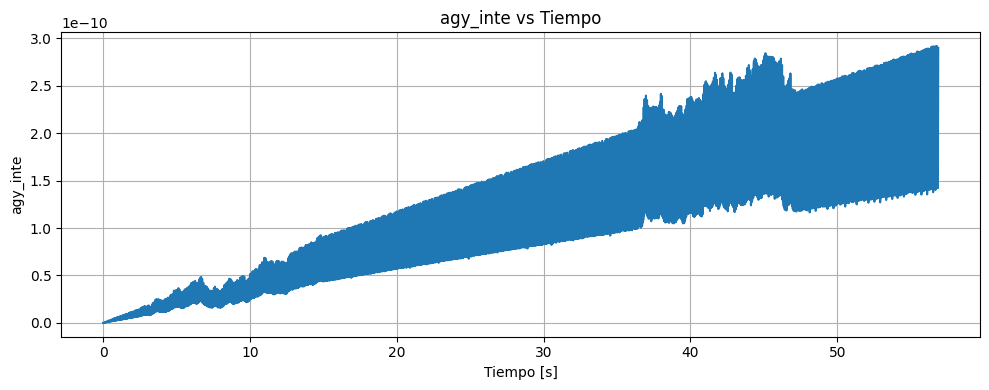

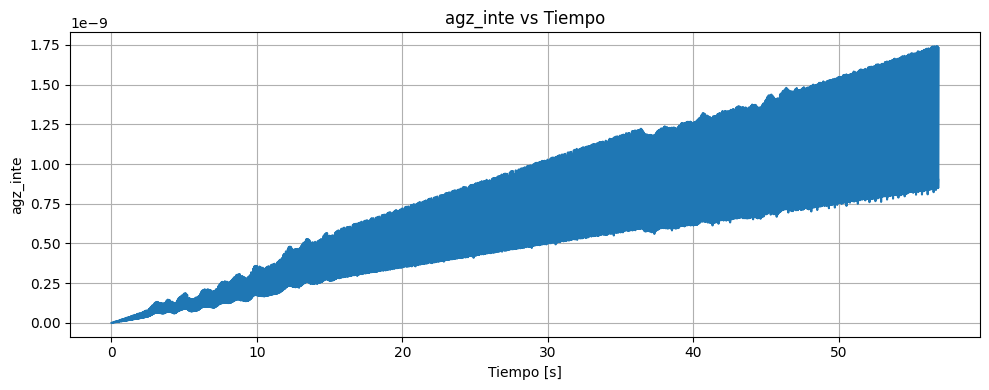

In [821]:
def plot_integ_data_vs_time(df, col_input):#, col_output):
    # df = df.copy()

    y = np.cumsum(df[col_input]) * df_merge["dt"]

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # y = df[col_output]

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_input+'_inte')
    plt.title(f"{col_input+'_inte'} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df_merge.columns[1:7]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)#col_output=column+"_inte")
    # print(column+"_inte", " u:", mean(df,column+"_inte"), " o2:", variance(df,column+"_inte")," o:", standard_deviation(df,column+"_inte"))
    # print(column+"_inte", " u:", mean(df, column), " o2:", variance(df, column)," o:", standard_deviation(df, column))

# for column in df.columns[1:]:
#     print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))

    

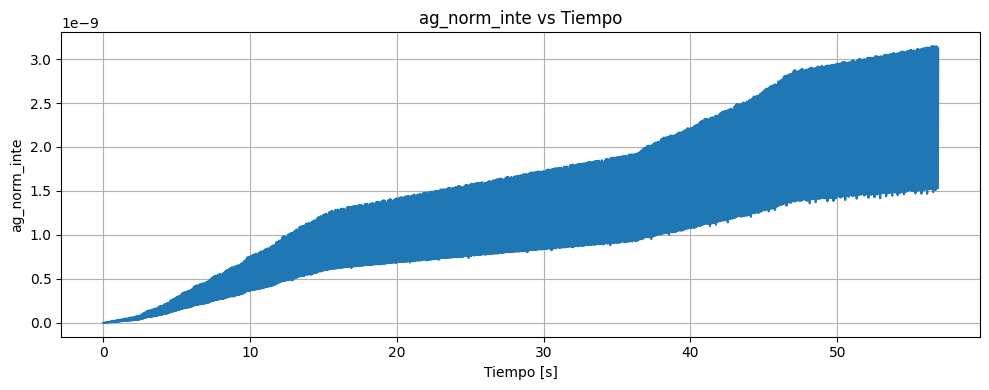

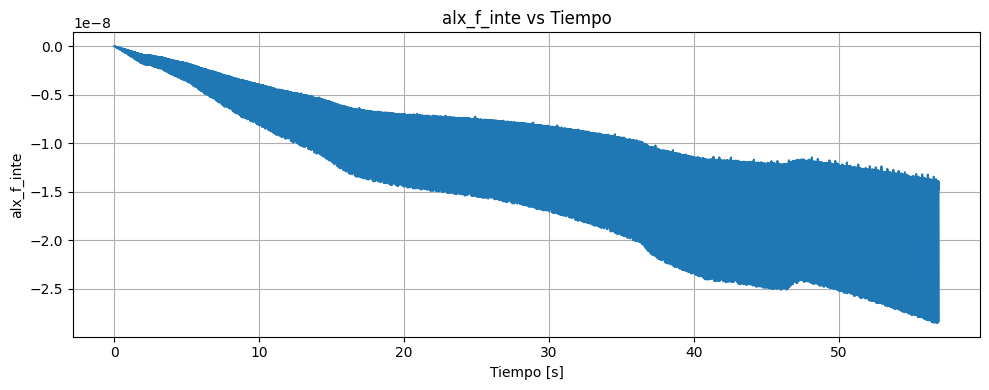

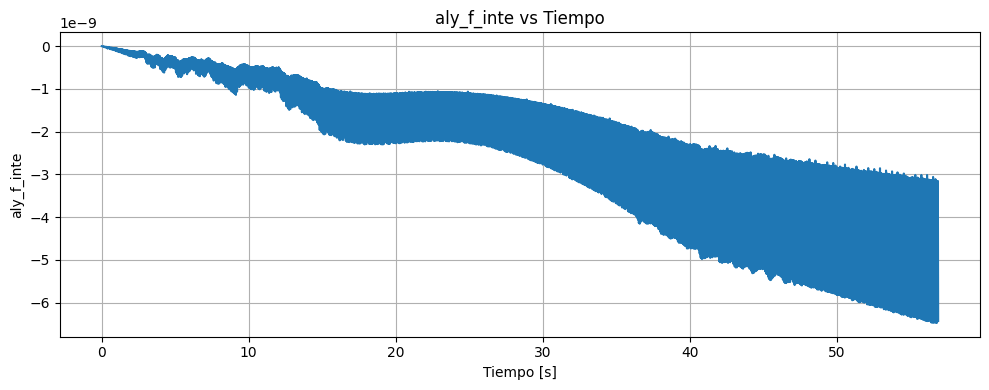

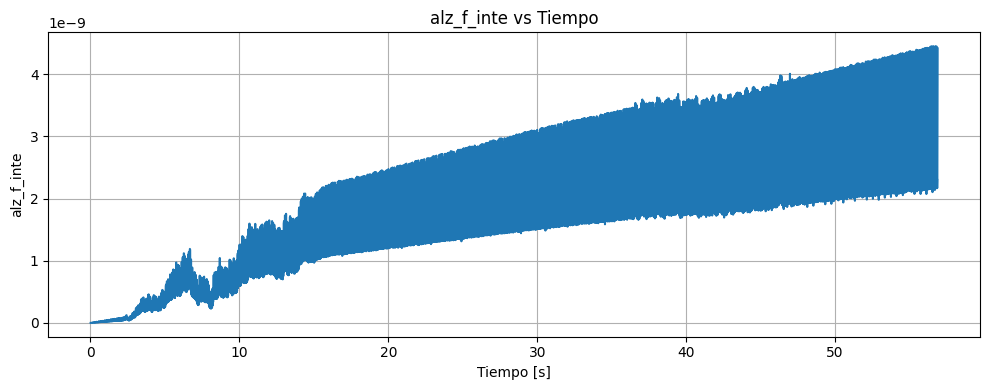

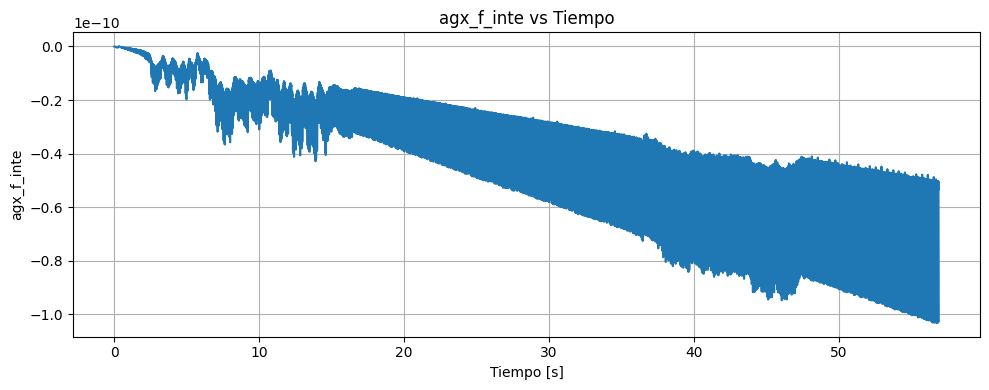

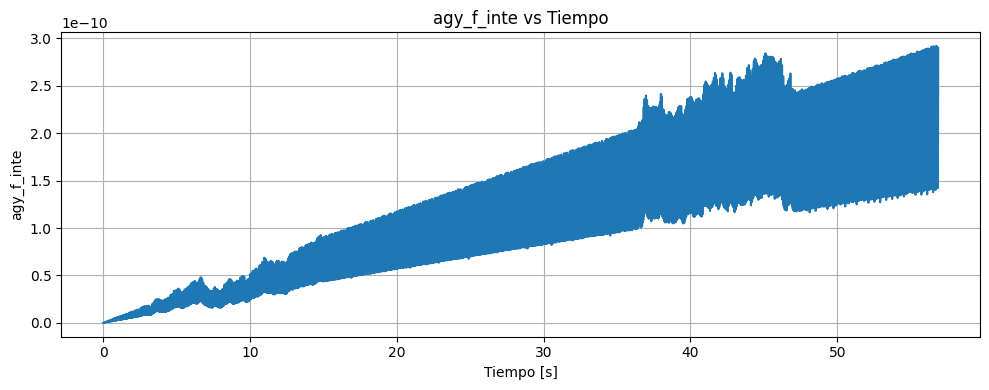

In [822]:
for column in df_merge.columns[15:21]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)

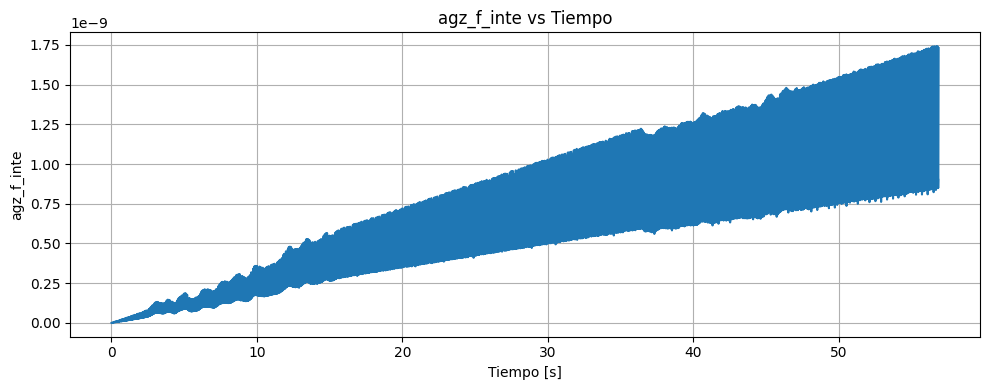

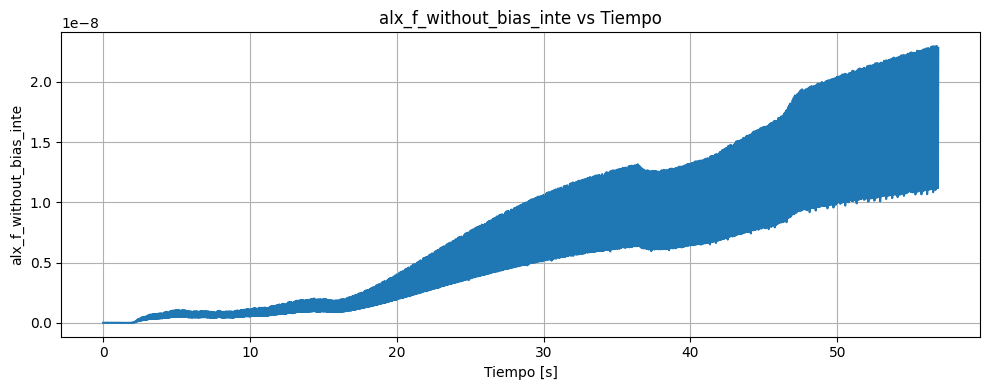

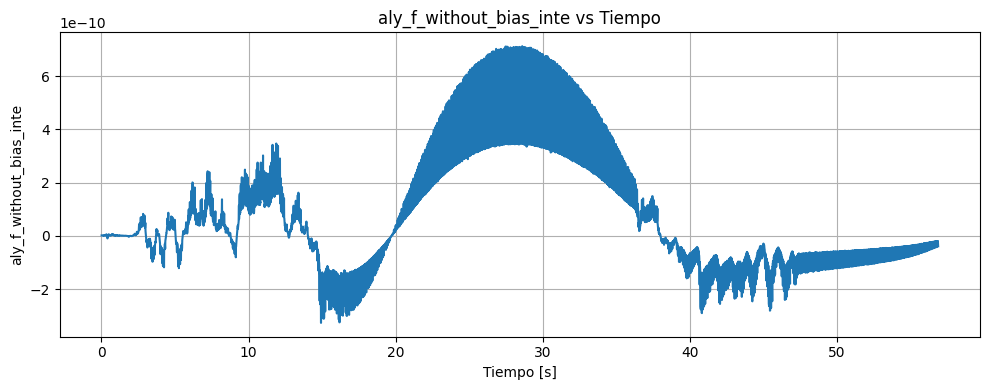

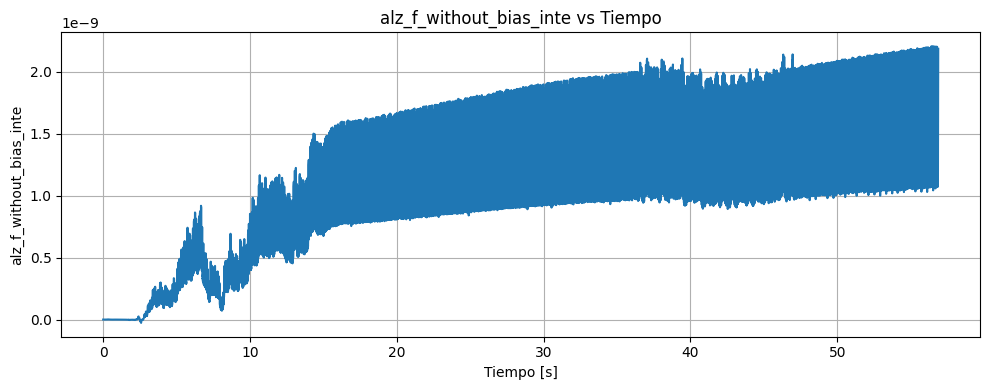

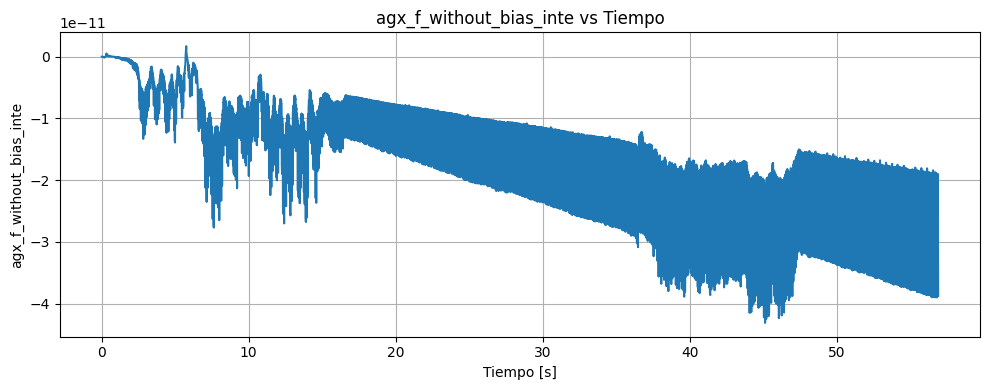

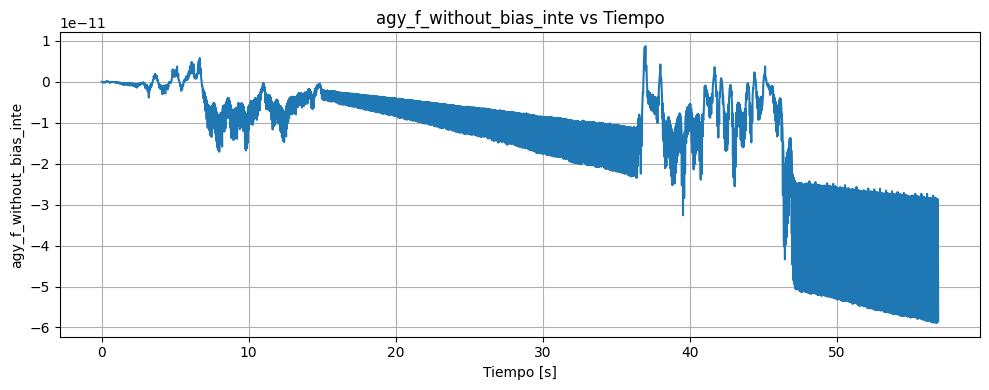

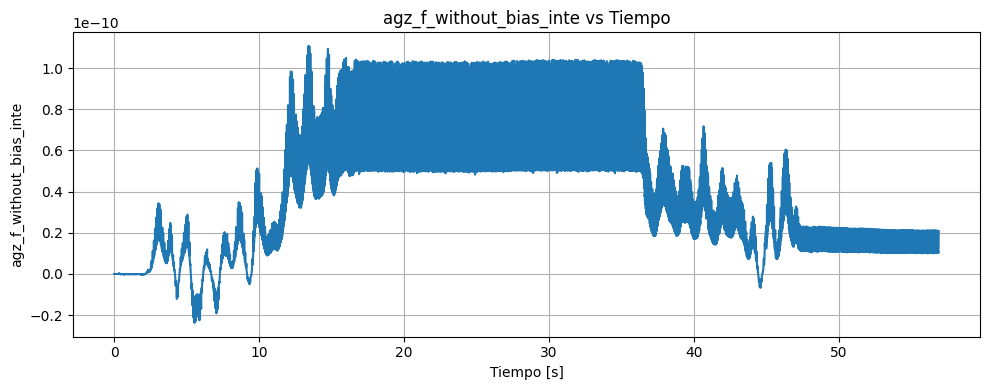

In [823]:
for column in df_merge.columns[21:28]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)

In [824]:
df_merge

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,...,alz_f,agx_f,agy_f,agz_f,alx_f_without_bias,aly_f_without_bias,alz_f_without_bias,agx_f_without_bias,agy_f_without_bias,agz_f_without_bias
0,1777415753006350596,-0.005004,0.029466,0.055045,-0.001042,0.003331,0.016892,0.999987,0.005049,0.000979,...,0.055037,-0.001023,0.003345,0.016898,0.552542,0.099280,0.030722,-0.000328,-0.000451,-0.001733
1,1777415753016559684,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,...,0.041370,-0.001151,0.002968,0.017515,0.337040,0.058394,0.017056,-0.000456,-0.000827,-0.001116
2,1777415753026651662,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,...,0.029687,-0.001246,0.002684,0.018063,0.152984,0.023709,0.005372,-0.000552,-0.001111,-0.000568
3,1777415753036301759,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,...,0.021369,-0.001282,0.002559,0.018491,0.022133,-0.000726,-0.002945,-0.000588,-0.001237,-0.000140
4,1777415753046387868,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,...,0.016877,-0.001252,0.002606,0.018774,-0.048884,-0.014105,-0.007437,-0.000557,-0.001189,0.000143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4697,1777415809836295834,-0.334132,-0.039574,0.040694,-0.001293,0.002965,0.017143,0.736187,-0.011030,0.013631,...,0.035440,-0.001474,0.002976,0.017445,0.225930,0.016514,0.011125,-0.000779,-0.000820,-0.001186
4698,1777415809846528987,-0.334132,-0.039574,0.040694,-0.001293,0.002965,0.017143,0.736187,-0.011030,0.013631,...,0.034115,-0.001504,0.002931,0.017381,0.222343,0.019982,0.009801,-0.000809,-0.000865,-0.001251
4699,1777415809856109952,-0.350269,-0.038060,0.028760,-0.001754,0.002797,0.017989,0.736063,-0.011060,0.013641,...,0.031395,-0.001493,0.002916,0.017431,0.217815,0.019944,0.007081,-0.000798,-0.000880,-0.001200
4700,1777415809866383216,-0.350269,-0.038060,0.028760,-0.001754,0.002797,0.017989,0.736063,-0.011060,0.013641,...,0.027438,-0.001448,0.002930,0.017567,0.212866,0.016301,0.003124,-0.000753,-0.000866,-0.001064


In [825]:

def normalized(x):
    x = np.asarray(x, dtype=float)
    n = np.linalg.norm(x)
    if n < 1e-12:
        return x
    return x / n

def I(n):
    '''
    unit matrix
    just making its name prettier than np.eye
    '''
    return np.eye(n)

def skew(x):
    '''
    takes in a 3d column vector
    returns its Skew-symmetric matrix
    '''

    x = x.T[0]
    return np.array([[0, -x[2], x[1]], [x[2], 0, -x[0]], [-x[1], x[0], 0]])

def rotate(q):
    '''
    rotation transformation matrix
    nav frame to body frame as q is expected to be q^nb
    R(q) @ x to rotate x
    '''

    qv = q[1:4, :]
    qc = q[0]
    return (qc**2 - qv.T @ qv) * I(3) - 2 * qc * skew(qv) + 2 * qv @ qv.T


In [826]:
import numpy as np

def compute_navigation_acceleration(
    df,
    # init,
    accel_cols=("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias"),
    quat_cols=("q0", "q1", "q2", "q3")
):
    """
    Calcula aceleración en marco navegación usando aceleración lineal del IMU
    y cuaternión.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame con aceleraciones y cuaterniones.

    init : dict
        Diccionario devuelto por initialize_from_dataframe(...).
        Debe contener init["gn"].

    accel_cols : tuple
        Columnas de aceleración en body/frame IMU.
        Ejemplo:
            ("alx", "aly", "alz")
            ("alx_f", "aly_f", "alz_f")
            ("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias")

    quat_cols : tuple
        Columnas de cuaternión.
        Por defecto: ("q0", "q1", "q2", "q3")

    Retorna
    -------
    df_out, orix, oriy, oriz
    """

    # gn = np.asarray(init["gn"], dtype=float).reshape(3, 1)

    required_cols = list(accel_cols) + list(quat_cols)
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    df_out = df.copy()

    a_nav = []
    orix = []
    oriy = []
    oriz = []

    init_ori = I(3)

    conj = -I(4)
    conj[0, 0] = 1

    for _, row in df_out.iterrows():

        at = np.array([
            [row[accel_cols[0]]],
            [row[accel_cols[1]]],
            [row[accel_cols[2]]]
        ], dtype=float)

        q = np.array([
            [row[quat_cols[0]]],
            [row[quat_cols[1]]],
            [row[quat_cols[2]]],
            [row[quat_cols[3]]]
        ], dtype=float)

        q = normalized(q)

        R_nb = rotate(conj @ q)

        an = R_nb @ at # + gn
        orin = R_nb @ init_ori

        a_nav.append(an.ravel())
        orix.append(orin[0, :])
        oriy.append(orin[1, :])
        oriz.append(orin[2, :])

    a_nav = np.array(a_nav)
    orix = np.array(orix)
    oriy = np.array(oriy)
    oriz = np.array(oriz)

    df_out["anx"] = a_nav[:, 0]
    df_out["any"] = a_nav[:, 1]
    df_out["anz"] = a_nav[:, 2]

    return df_out, orix, oriy, oriz

In [827]:
df_nav, orix, oriy, oriz = compute_navigation_acceleration(
    df_merge,
    accel_cols=("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias")
)

In [828]:
df_nav.head()

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,...,agz_f,alx_f_without_bias,aly_f_without_bias,alz_f_without_bias,agx_f_without_bias,agy_f_without_bias,agz_f_without_bias,anx,any,anz
0,1777415753006350596,-0.005004,0.029466,0.055045,-0.001042,0.003331,0.016892,0.999987,0.005049,0.000979,...,0.016898,0.552542,0.099280,0.030722,-0.000328,-0.000451,-0.001733,0.552564,0.099181,0.030642
1,1777415753016559684,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,...,0.017515,0.337040,0.058394,0.017056,-0.000456,-0.000827,-0.001116,0.283756,0.191766,-0.002195
2,1777415753026651662,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,...,0.018063,0.152984,0.023709,0.005372,-0.000552,-0.001111,-0.000568,0.129821,0.084441,-0.003366
3,1777415753036301759,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,...,0.018491,0.022133,-0.000726,-0.002945,-0.000588,-0.001237,-0.000140,0.020288,0.008352,-0.004211
4,1777415753046387868,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,...,0.018774,-0.048884,-0.014105,-0.007437,-0.000557,-0.001189,0.000143,-0.039093,-0.033077,-0.004643


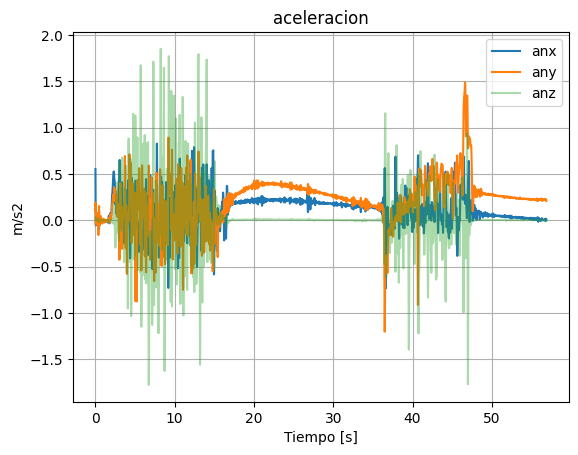

In [829]:
plt.figure()
plt.plot(df_nav["timestamp"], df_nav["anx"], label="anx")
plt.plot(df_nav["timestamp"], df_nav["any"], label="any")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(df_nav["timestamp"], df_nav["anz"], label="anz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion")
plt.show()

In [830]:
def zupt_df_from_flag_variable_dt(
    df,
    dt_col="dt",
    acc_cols=("anx", "any", "anz"),
    flag_col="flagStop",
    vel_cols=("vnx", "vny", "vnz"),
):
    """
    Aplica ZUPT usando flagStop y dt variable por muestra.

    Requiere columnas:
        anx, any, anz
        dt
        flagStop

    Donde:
        flagStop = 0 -> avance
        flagStop = 1 -> parado
    """

    df = df.copy()
    print(df.head())
    required_cols = list(acc_cols) + [dt_col, flag_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    for c in acc_cols + (dt_col,):
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df[flag_col] = pd.to_numeric(df[flag_col], errors="coerce").fillna(0).astype(int)

    df = df.dropna(subset=list(acc_cols) + [dt_col]).reset_index(drop=True)

    a_nav = df[list(acc_cols)].to_numpy(dtype=float)
    dt_array = df[dt_col].to_numpy(dtype=float)
    flag_stop = df[flag_col].to_numpy(dtype=int)

    sample_number = len(df)

    velocities = []
    zupt_flags = []

    prevt = -1
    still_phase = False

    v = np.zeros((3, 1))

    for t in range(sample_number):

        at = a_nav[t].reshape(3, 1)
        dt = dt_array[t]

        if flag_stop[t] == 1:

            zupt_flags.append(1)

            if not still_phase:

                predict_v = v + at * dt

                denom = t - prevt

                if denom > 0:
                    v_drift_rate = predict_v / denom

                    for i in range(t - prevt - 1):
                        idx = prevt + 1 + i
                        velocities[idx] -= (i + 1) * v_drift_rate.T[0]

            v = np.zeros((3, 1))
            prevt = t
            still_phase = True

        else:
            zupt_flags.append(0)

            v = v + at * dt
            still_phase = False

        velocities.append(v.T[0])

    velocities = np.array(velocities)

    df[vel_cols[0]] = velocities[:, 0]
    df[vel_cols[1]] = velocities[:, 1]
    df[vel_cols[2]] = velocities[:, 2]

    df["zupt_flag"] = zupt_flags

    return df

In [831]:
# import numpy as np

# def zupt_df(df, dt=0.005, threshold=0.02):
#     """
#     Aplica ZUPT usando aceleración en navegación desde un DataFrame.

#     Requiere columnas:
#         anx, any, anz

#     Agrega columnas:
#         vnx, vny, vnz
#         zupt_flag
#     """

#     df = df.copy()

#     # Pasar aceleración navegación a array Nx3
#     a_nav = df[["anx", "any", "anz"]].to_numpy(dtype=float)

#     sample_number = a_nav.shape[0]

#     velocities = []
#     zupt_flags = []

#     prevt = -1
#     still_phase = False

#     v = np.zeros((3, 1))

#     for t in range(sample_number):

#         at = a_nav[t].reshape(3, 1)

#         if np.linalg.norm(at) < threshold:
#             zupt_flags.append(1)

#             if not still_phase:
#                 predict_v = v + at * dt

#                 denom = t - prevt

#                 if denom > 0:
#                     v_drift_rate = predict_v / denom

#                     for i in range(t - prevt - 1):
#                         velocities[prevt + 1 + i] -= (i + 1) * v_drift_rate.T[0]

#             v = np.zeros((3, 1))
#             prevt = t
#             still_phase = True

#         else:
#             zupt_flags.append(0)

#             v = v + at * dt
#             still_phase = False

#         velocities.append(v.T[0])

#     velocities = np.array(velocities)

#     df["vnx"] = velocities[:, 0]
#     df["vny"] = velocities[:, 1]
#     df["vnz"] = velocities[:, 2]

#     df["zupt_flag"] = zupt_flags

#     return df

In [832]:
# df_zupt = zupt_df_from_flag(
#     df_nav,
#     dt=0.01,
#     threshold=0.02
# )
# df_zupt = zupt_df_from_flag(
#     df_merge,
#     dt=0.01,
#     acc_cols=("anx", "any", "anz"),
#     flag_col="flagStop"
# )
df_zupt = zupt_df_from_flag_variable_dt(
    df_nav,
    dt_col="dt",
    acc_cols=("anx", "any", "anz"),
    flag_col="flagStop"
)

                  Time       alx       aly       alz       agx       agy  \
0  1777415753006350596 -0.005004  0.029466  0.055045 -0.001042  0.003331   
1  1777415753016559684 -0.545940 -0.106244  0.026371 -0.001580  0.001981   
2  1777415753026651662 -0.545940 -0.106244  0.026371 -0.001580  0.001981   
3  1777415753036301759 -0.555377 -0.059631  0.015700 -0.001255  0.002622   
4  1777415753046387868 -0.555377 -0.059631  0.015700 -0.001255  0.002622   

        agz        q0        q1        q2  ...     agz_f  alx_f_without_bias  \
0  0.016892  0.999987  0.005049  0.000979  ...  0.016898            0.552542   
1  0.018396  0.977315 -0.005265  0.028184  ...  0.017515            0.337040   
2  0.018396  0.977315 -0.005265  0.028184  ...  0.018063            0.152984   
3  0.018263  0.977277 -0.005277  0.028206  ...  0.018491            0.022133   
4  0.018263  0.977277 -0.005277  0.028206  ...  0.018774           -0.048884   

   aly_f_without_bias  alz_f_without_bias  agx_f_without_bias 

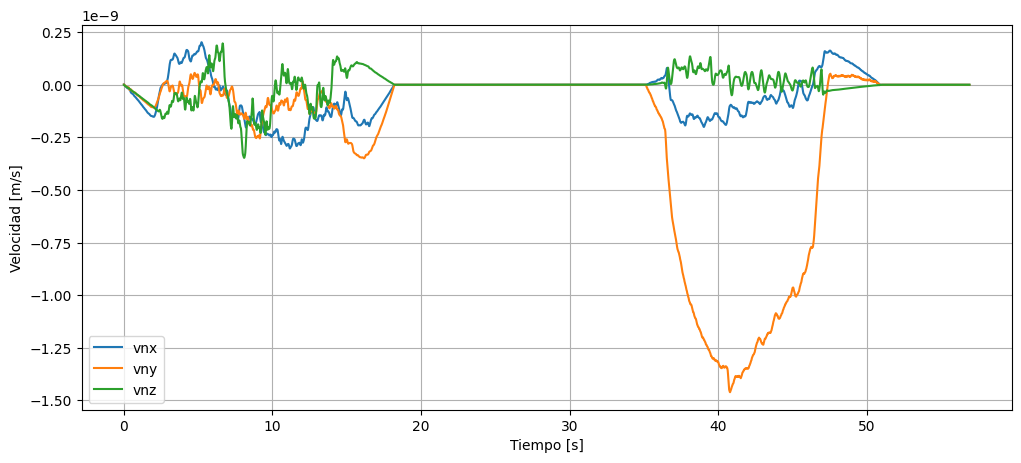

In [833]:
import matplotlib.pyplot as plt

t = df_zupt["timestamp"] if "timestamp" in df_zupt.columns else np.arange(len(df_zupt))

plt.figure(figsize=(12, 5))
plt.plot(t, df_zupt["vnx"], label="vnx")
plt.plot(t, df_zupt["vny"], label="vny")
plt.plot(t, df_zupt["vnz"], label="vnz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.grid()
plt.legend()
plt.show()

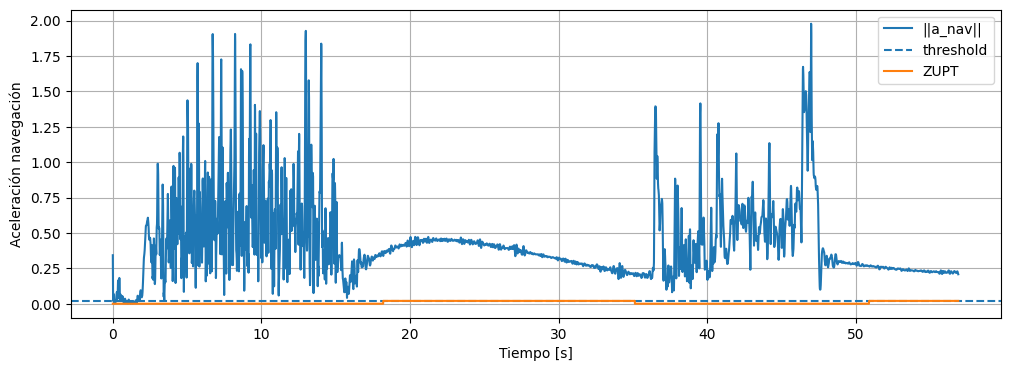

In [834]:
a_norm = np.linalg.norm(df_zupt[["anx", "any", "anz"]].to_numpy(), axis=1)

plt.figure(figsize=(12, 4))
plt.plot(t, a_norm, label="||a_nav||")
plt.axhline(0.02, linestyle="--", label="threshold")
plt.plot(t, df_zupt["zupt_flag"] * 0.02, label="ZUPT")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración navegación")
plt.grid()
plt.legend()
plt.show()

In [835]:
import numpy as np

def position_df(df, dt=0.01, use_dt_col=True):
    """
    Integra posición usando velocidad ZUPT.

    Requiere:
        vnx, vny, vnz

    Opcional:
        dt

    Agrega:
        px, py, pz, pnorm
    """

    df = df.copy()

    velocities = df[["vnx", "vny", "vnz"]].to_numpy(dtype=float)

    positions = []
    p = np.zeros((3, 1))

    for t in range(len(df)):

        vt = velocities[t].reshape(3, 1)

        if use_dt_col and "dt" in df.columns:
            dtk = float(df["dt"].iloc[t])

            if not np.isfinite(dtk) or dtk <= 0:
                dtk = dt
        else:
            dtk = dt

        p = p + vt * dtk

        positions.append(p.T[0])

    positions = np.array(positions)

    df["px"] = positions[:, 0]
    df["py"] = positions[:, 1]
    df["pz"] = positions[:, 2]

    df["pnorm"] = np.linalg.norm(positions, axis=1)

    return df

In [836]:
df_pos = position_df(df_zupt, dt=0.01)

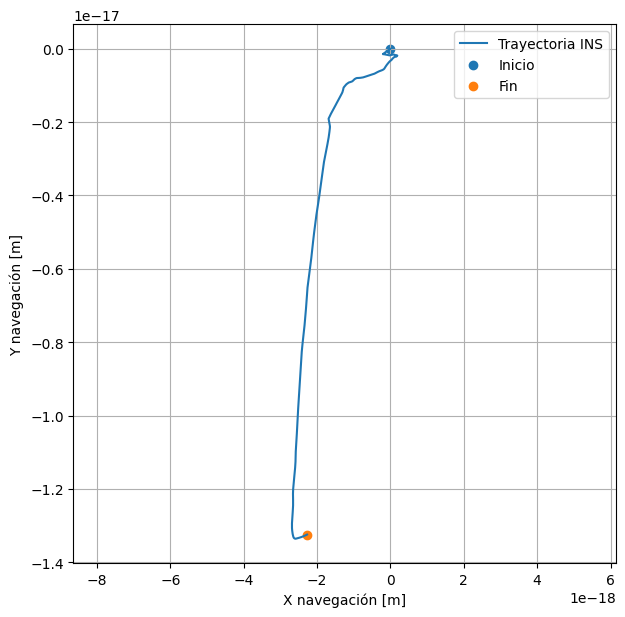

In [837]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_pos["px"], df_pos["py"], label="Trayectoria INS")
plt.scatter(df_pos["px"].iloc[0], df_pos["py"].iloc[0], label="Inicio")
plt.scatter(df_pos["px"].iloc[-1], df_pos["py"].iloc[-1], label="Fin")
plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

In [838]:
import numpy as np

def nhc_df(df, K_nhc_y=1.0, K_nhc_z=1.0):
    """
    Aplica Non-Holonomic Constraint a la velocidad.

    Requiere columnas:
        vnx, vny, vnz
        q0, q1, q2, q3

    Agrega columnas:
        vbx_raw, vby_raw, vbz_raw
        vbx_nhc, vby_nhc, vbz_nhc
        vnx_nhc, vny_nhc, vnz_nhc
    """

    df = df.copy()

    required_cols = ["vnx", "vny", "vnz", "q0", "q1", "q2", "q3"]
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    conj = -I(4)
    conj[0, 0] = 1

    v_body_raw_list = []
    v_body_nhc_list = []
    v_nav_nhc_list = []

    for _, row in df.iterrows():

        # Velocidad en navegación
        v_nav = np.array([
            [row["vnx"]],
            [row["vny"]],
            [row["vnz"]]
        ], dtype=float)

        # Cuaternión q = [q0, q1, q2, q3]
        q = np.array([
            [row["q0"]],
            [row["q1"]],
            [row["q2"]],
            [row["q3"]]
        ], dtype=float)

        q = normalized(q)

        # Según tu convención:
        # rotate(conj @ q) = body -> nav
        # rotate(q)        = nav -> body
        v_body = rotate(q) @ v_nav

        vx_b = v_body[0, 0]
        vy_b = v_body[1, 0]
        vz_b = v_body[2, 0]

        # Aplicar NHC:
        # El vehículo no debería tener velocidad lateral ni vertical en body.
        vy_b_corr = vy_b * (1.0 - K_nhc_y)
        vz_b_corr = vz_b * (1.0 - K_nhc_z)

        v_body_corr = np.array([
            [vx_b],
            [vy_b_corr],
            [vz_b_corr]
        ], dtype=float)

        # Volver de body -> navegación
        v_nav_corr = rotate(conj @ q) @ v_body_corr

        v_body_raw_list.append(v_body.T[0])
        v_body_nhc_list.append(v_body_corr.T[0])
        v_nav_nhc_list.append(v_nav_corr.T[0])

    v_body_raw = np.array(v_body_raw_list)
    v_body_nhc = np.array(v_body_nhc_list)
    v_nav_nhc = np.array(v_nav_nhc_list)

    df["vbx_raw"] = v_body_raw[:, 0]
    df["vby_raw"] = v_body_raw[:, 1]
    df["vbz_raw"] = v_body_raw[:, 2]

    df["vbx_nhc"] = v_body_nhc[:, 0]
    df["vby_nhc"] = v_body_nhc[:, 1]
    df["vbz_nhc"] = v_body_nhc[:, 2]

    df["vnx_nhc"] = v_nav_nhc[:, 0]
    df["vny_nhc"] = v_nav_nhc[:, 1]
    df["vnz_nhc"] = v_nav_nhc[:, 2]

    return df

In [839]:
df_nhc = nhc_df(
    df_zupt,
    K_nhc_y=1.0,
    K_nhc_z=1.0
)

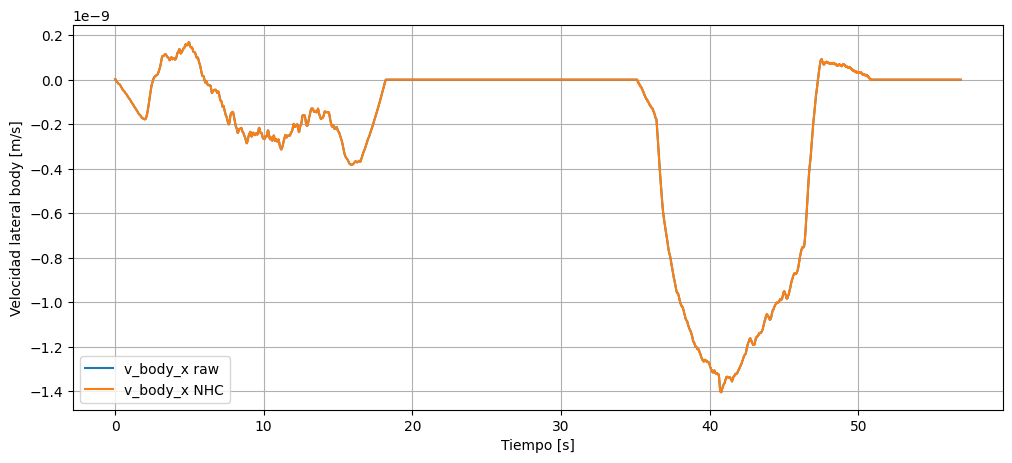

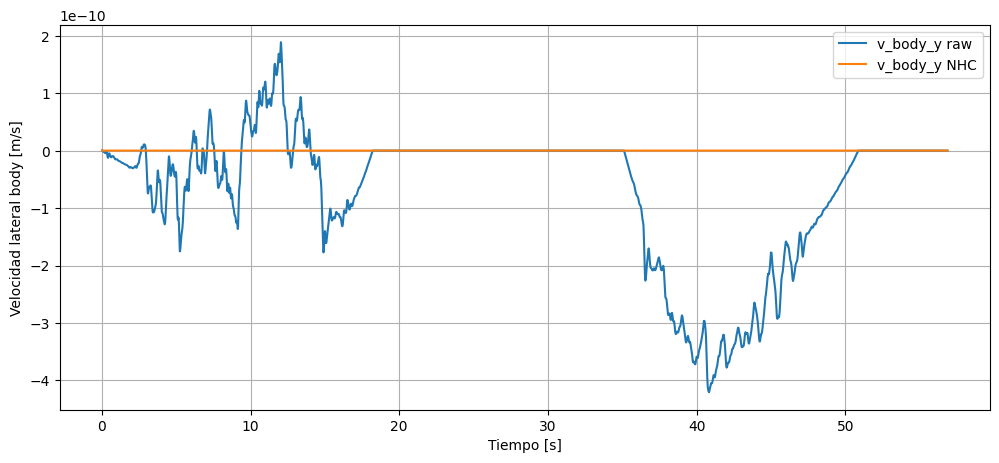

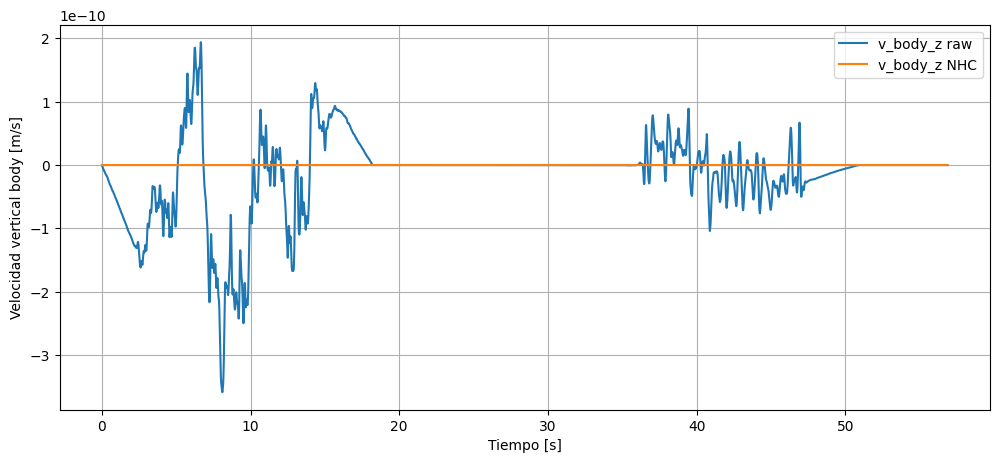

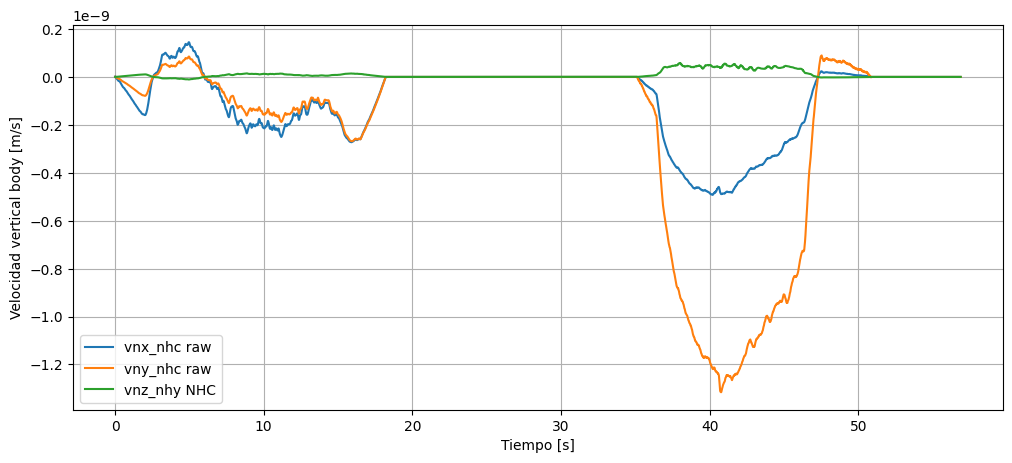

In [844]:
import matplotlib.pyplot as plt

t = df_nhc["timestamp"] if "timestamp" in df_nhc.columns else np.arange(len(df_nhc))

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vbx_raw"], label="v_body_x raw")
plt.plot(t, df_nhc["vbx_nhc"], label="v_body_x NHC")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad lateral body [m/s]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vby_raw"], label="v_body_y raw")
plt.plot(t, df_nhc["vby_nhc"], label="v_body_y NHC")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad lateral body [m/s]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vbz_raw"], label="v_body_z raw")
plt.plot(t, df_nhc["vbz_nhc"], label="v_body_z NHC")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad vertical body [m/s]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vnx_nhc"], label="vnx_nhc raw")
plt.plot(t, df_nhc["vny_nhc"], label="vny_nhc raw")
plt.plot(t, df_nhc["vnz_nhc"], label="vnz_nhy NHC")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad vertical body [m/s]")
plt.grid()
plt.legend()
plt.show()

In [841]:
df_pos = position_df(
    df_nhc,
    dt=0.01,
    vel_cols=("vnx_nhc", "vny_nhc", "vnz_nhc")
)

TypeError: position_df() got an unexpected keyword argument 'vel_cols'